# PCA Assignment — Wine Dataset

## Objective
The objective of this assignment is to apply **Principal Component Analysis (PCA)** for dimensionality reduction and compare clustering performance on:

1. Original standardized dataset  
2. PCA-transformed dataset  

Dataset used: `wine.csv`

This notebook includes:

1. Exploratory Data Analysis  
2. Feature distributions  
3. Correlation analysis  
4. Standardization  
5. PCA implementation  
6. Scree plot and cumulative explained variance  
7. K-Means clustering on original data  
8. K-Means clustering on PCA data  
9. Silhouette score and Davies-Bouldin index comparison  
10. Final analysis, insights, and recommendations

## 1. Install Required Libraries

In [3]:
# Run this cell only if libraries are missing
# !pip install pandas numpy matplotlib seaborn scikit-learn

## 2. Import Required Libraries

In [4]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# Task 1: Exploratory Data Analysis

## 3. Load Dataset

In [5]:
df = pd.read_csv("wine.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (178, 14)


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 4. Dataset Information

The dataset contains wine chemical properties.

Column `Type` represents the wine class/group.

For PCA and clustering, we use only numerical feature columns and exclude `Type`.

In [6]:
print("Dataset Information:")
df.info()

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB

Column Names:
['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols

## 5. Missing Values and Duplicate Check

In [7]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicate rows if present
df = df.drop_duplicates()

print("\nShape after removing duplicates:", df.shape)

Missing Values:
Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

Duplicate Rows: 0

Shape after removing duplicates: (178, 14)


## 6. Summary Statistics

In [8]:
display(df.describe())

print("Type Distribution:")
print(df["Type"].value_counts().sort_index())

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Type Distribution:
Type
1    59
2    71
3    48
Name: count, dtype: int64


## 7. Wine Type Distribution

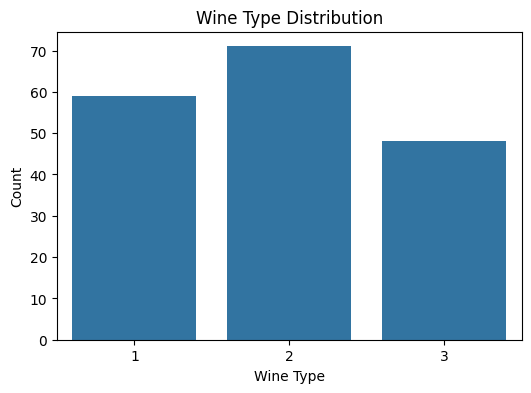

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Type")
plt.title("Wine Type Distribution")
plt.xlabel("Wine Type")
plt.ylabel("Count")
plt.show()

## 8. Feature Distribution using Histograms

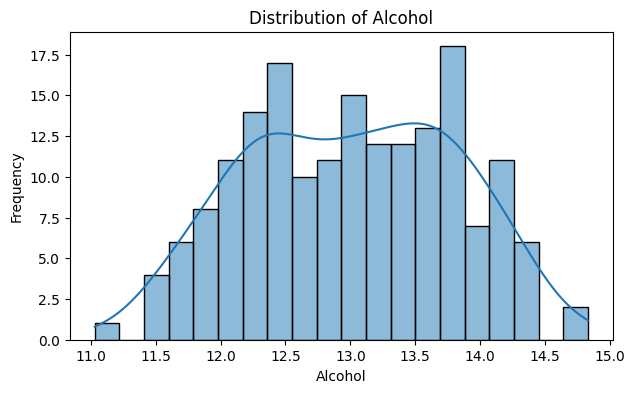

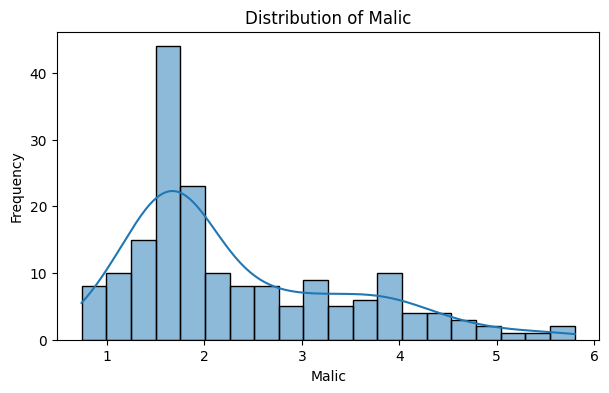

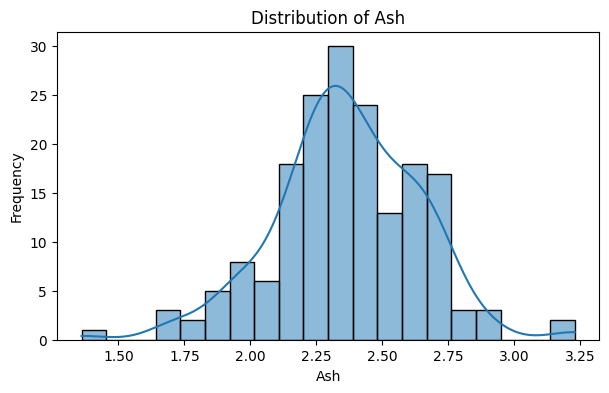

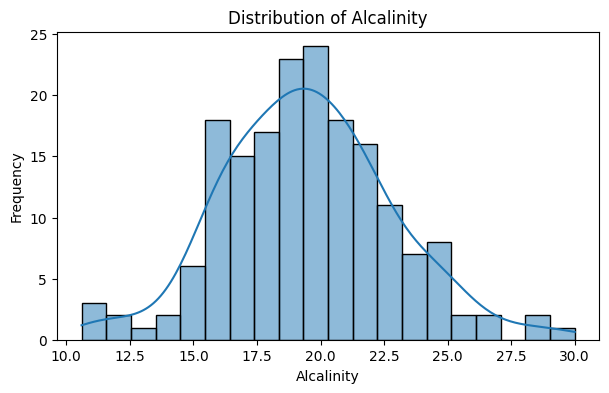

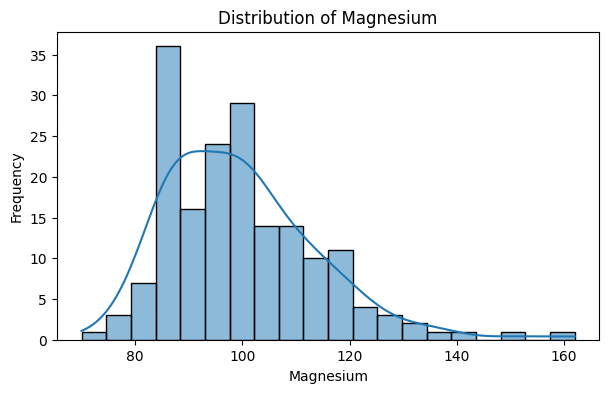

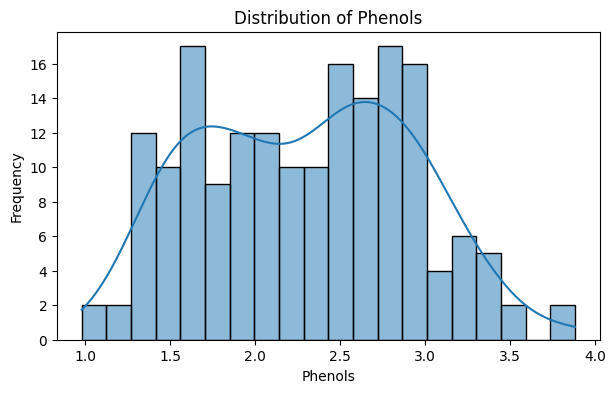

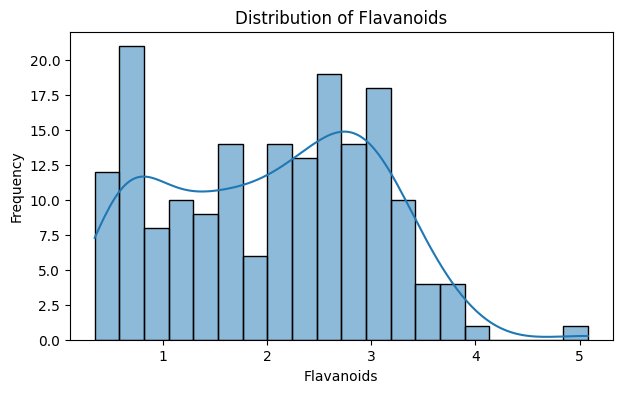

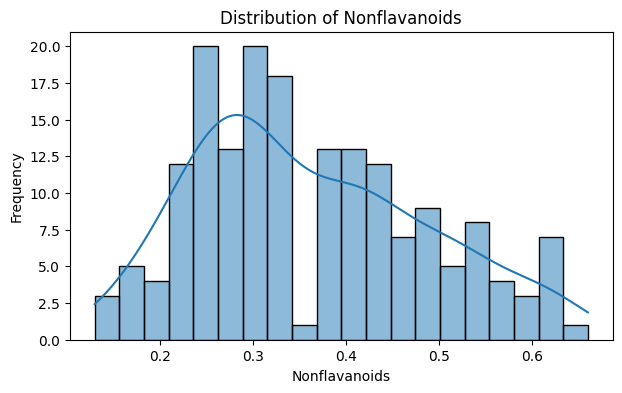

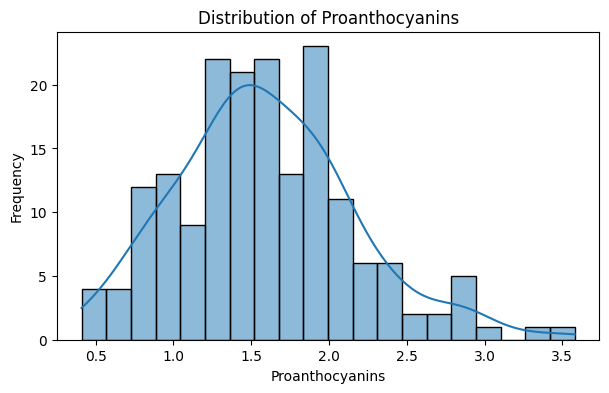

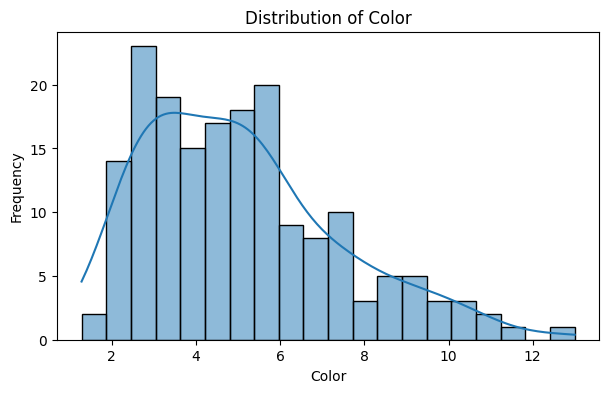

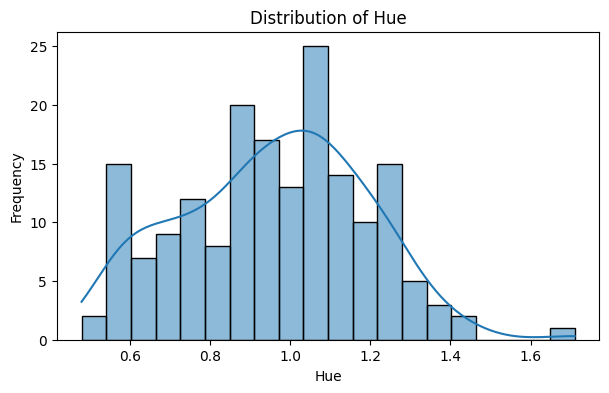

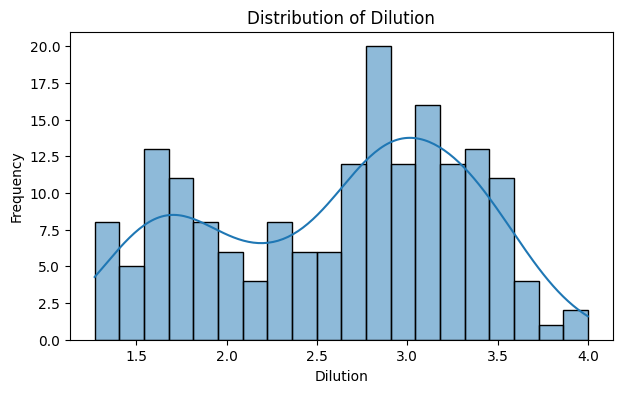

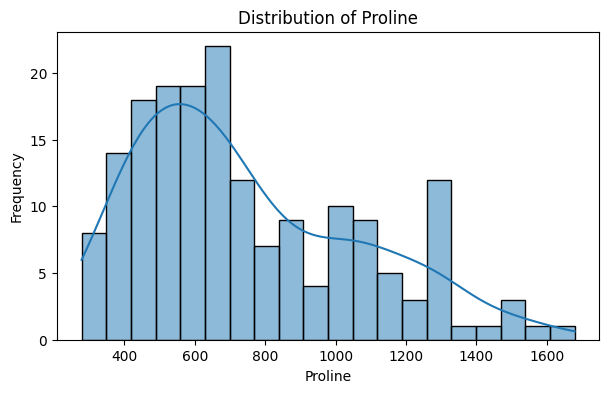

In [10]:
feature_cols = [col for col in df.columns if col != "Type"]

for col in feature_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## 9. Boxplots for Outlier Detection

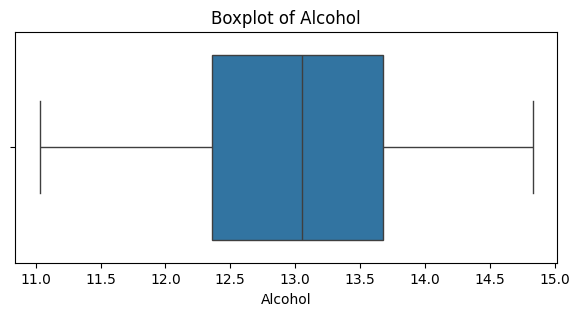

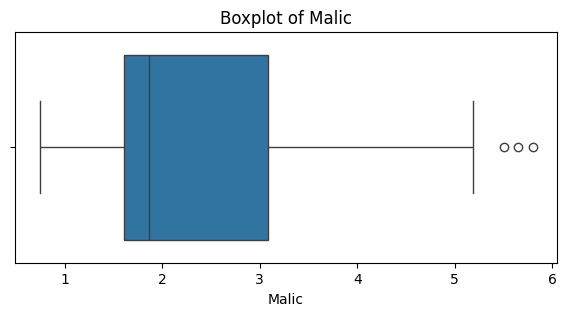

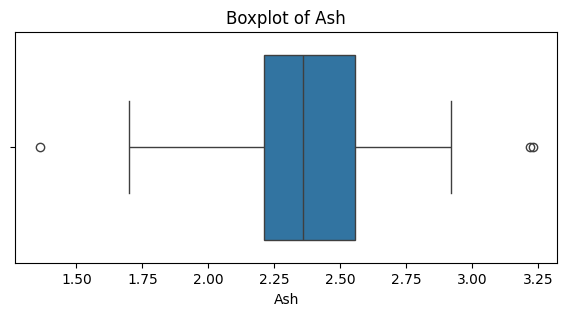

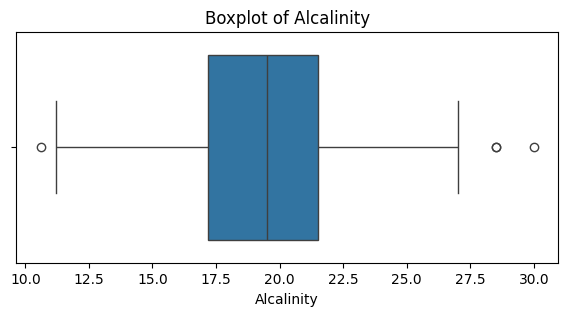

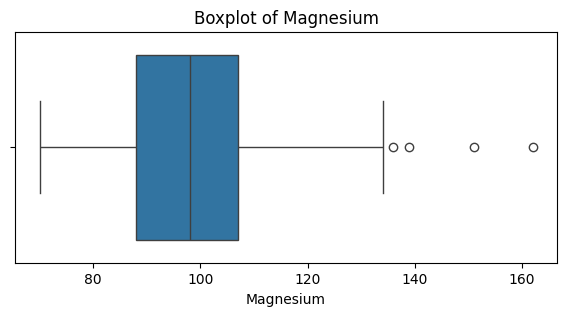

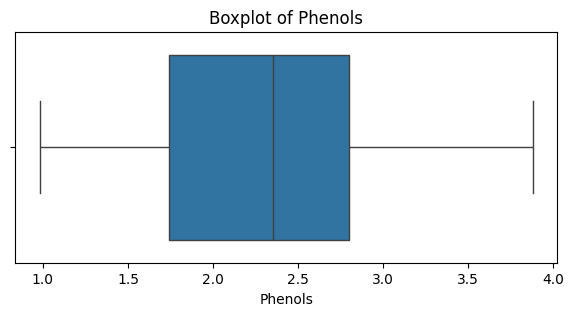

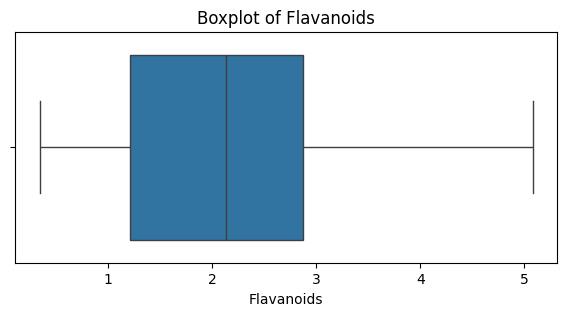

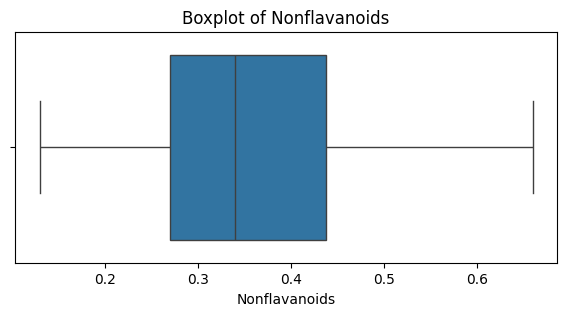

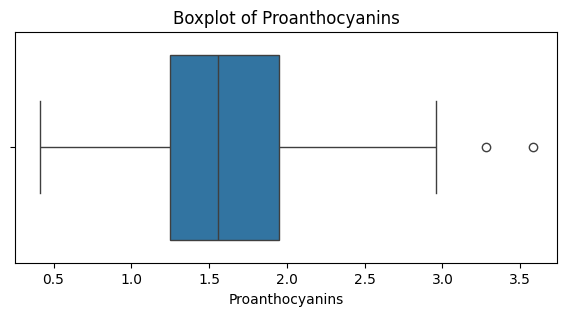

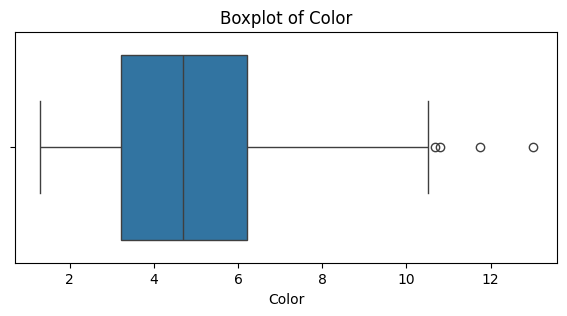

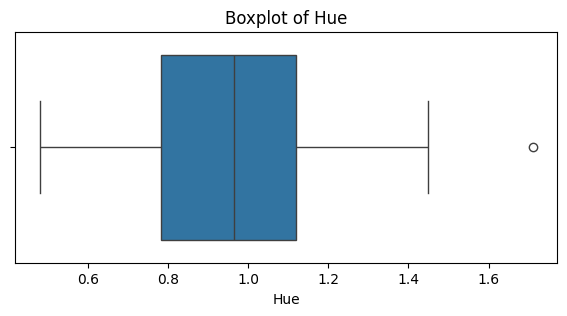

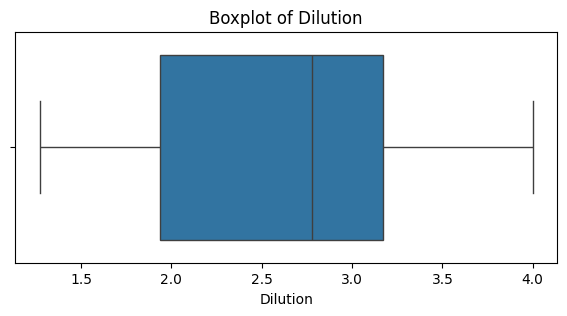

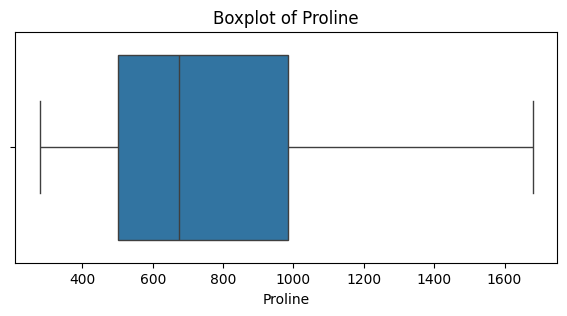

In [11]:
for col in feature_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

## 10. Correlation Heatmap

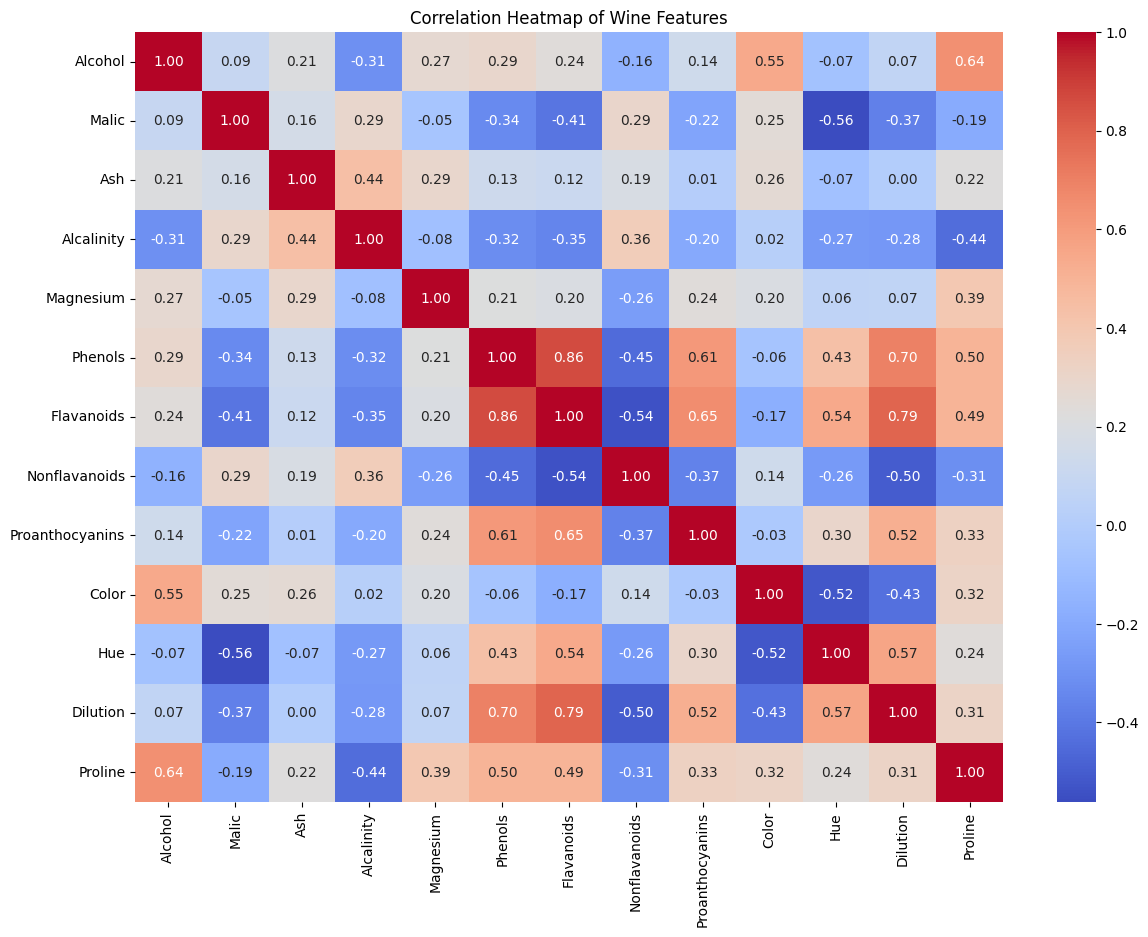

In [12]:
plt.figure(figsize=(14,10))
corr_matrix = df[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Wine Features")
plt.show()

## 11. Pair Plot for Important Features

Pair plot helps visualize separation between wine types using selected features.

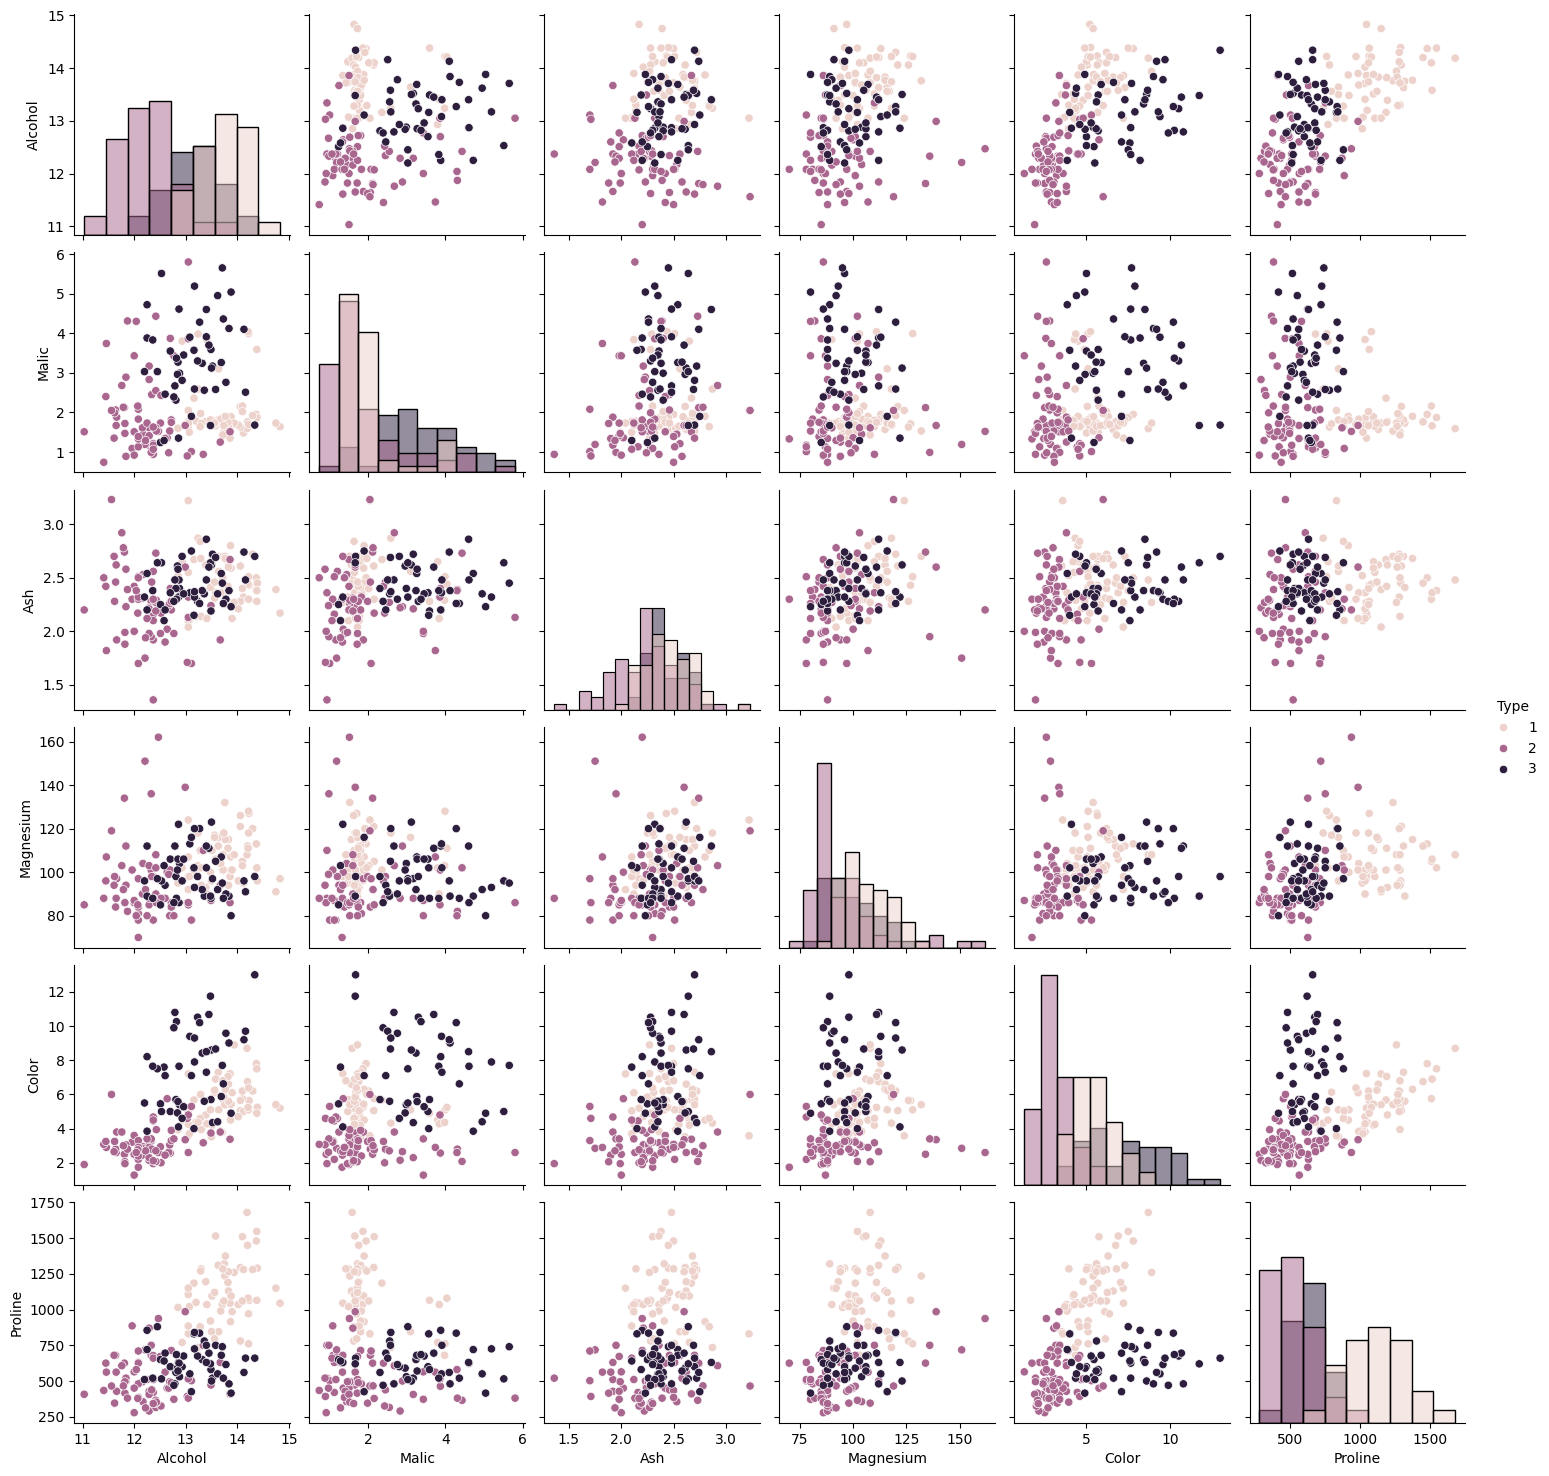

In [13]:
selected_pair_cols = ["Alcohol", "Malic", "Ash", "Magnesium", "Color", "Proline", "Type"]

sns.pairplot(df[selected_pair_cols], hue="Type", diag_kind="hist")
plt.show()

# Task 2: Dimensionality Reduction with PCA

## 12. Separate Features and Target

Although clustering is unsupervised, we keep `Type` separately only for visual reference.

In [14]:
X = df.drop(columns=["Type"])
y = df["Type"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

display(X.head())

Feature Shape: (178, 13)
Target Shape: (178,)


,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 13. Standardize the Features

PCA is affected by feature scale, so all features must be standardized.

Standardization makes:

- Mean = 0
- Standard deviation = 1

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Standardized Data:")
display(X_scaled_df.head())

print("\nMean after scaling:")
display(X_scaled_df.mean().round(4))

print("\nStandard deviation after scaling:")
display(X_scaled_df.std().round(4))

Standardized Data:


,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874



Mean after scaling:


Alcohol           -0.0
Malic             -0.0
Ash               -0.0
Alcalinity        -0.0
Magnesium         -0.0
Phenols            0.0
Flavanoids        -0.0
Nonflavanoids      0.0
Proanthocyanins   -0.0
Color              0.0
Hue                0.0
Dilution           0.0
Proline           -0.0
dtype: float64


Standard deviation after scaling:


Alcohol            1.0028
Malic              1.0028
Ash                1.0028
Alcalinity         1.0028
Magnesium          1.0028
Phenols            1.0028
Flavanoids         1.0028
Nonflavanoids      1.0028
Proanthocyanins    1.0028
Color              1.0028
Hue                1.0028
Dilution           1.0028
Proline            1.0028
dtype: float64

## 14. Apply PCA

In [16]:
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance Ratio": explained_variance,
    "Cumulative Explained Variance": cumulative_variance
})

display(pca_summary)

,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.361988,0.361988
1,PC2,0.192075,0.554063
2,PC3,0.111236,0.665300
3,PC4,0.070690,0.735990
4,PC5,0.065633,0.801623
5,PC6,0.049358,0.850981
6,PC7,0.042387,0.893368
7,PC8,0.026807,0.920175
8,PC9,0.022222,0.942397
9,PC10,0.019300,0.961697


## 15. Scree Plot

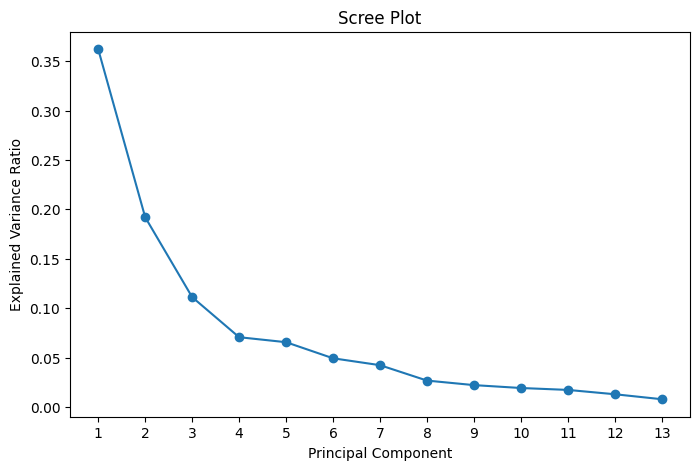

In [17]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, len(explained_variance) + 1))
plt.show()

## 16. Cumulative Explained Variance Plot

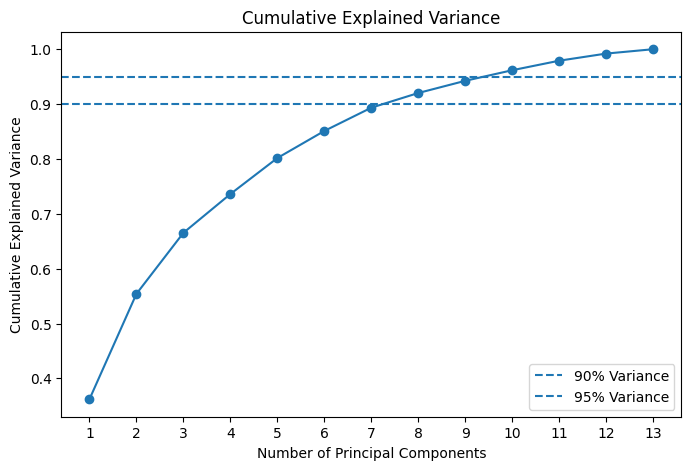

Number of components for 90% variance: 8
Number of components for 95% variance: 10


In [18]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.90, linestyle="--", label="90% Variance")
plt.axhline(y=0.95, linestyle="--", label="95% Variance")
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()
plt.show()

optimal_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
optimal_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Number of components for 90% variance:", optimal_components_90)
print("Number of components for 95% variance:", optimal_components_95)

## 17. Transform Dataset into Principal Components

For visualization and clustering comparison, we use the first 2 principal components.

In [19]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_2_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])
pca_2_df["Type"] = y.values

display(pca_2_df.head())

print("Explained variance by first 2 components:")
print(pca_2.explained_variance_ratio_)

print("Total variance explained by first 2 components:")
print(pca_2.explained_variance_ratio_.sum())

,PC1,PC2,Type
0,3.316751,1.443463,1
1,2.209465,-0.333393,1
2,2.516740,1.031151,1
3,3.757066,2.756372,1
4,1.008908,0.869831,1


Explained variance by first 2 components:
[0.36198848 0.1920749 ]
Total variance explained by first 2 components:
0.5540633835693527


## 18. PCA Visualization with Actual Type

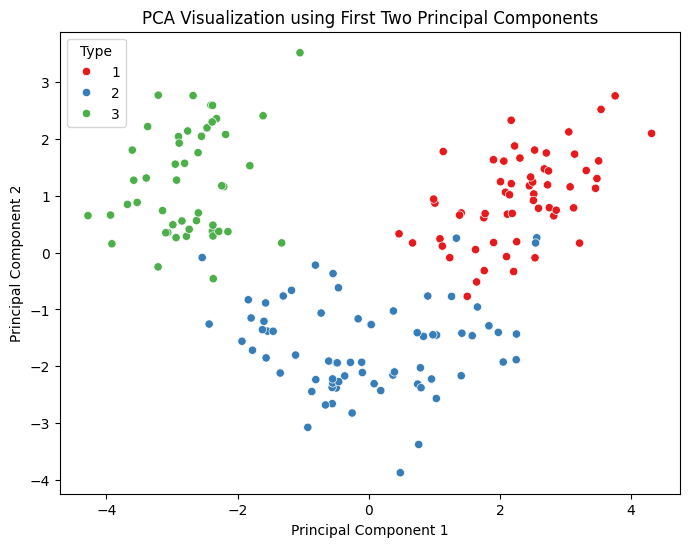

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_2_df, x="PC1", y="PC2", hue="Type", palette="Set1")
plt.title("PCA Visualization using First Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Task 3: Clustering with Original Data

## 19. Elbow Method for Original Data

K-Means requires selecting the number of clusters `k`.

The elbow method helps find a suitable `k`.

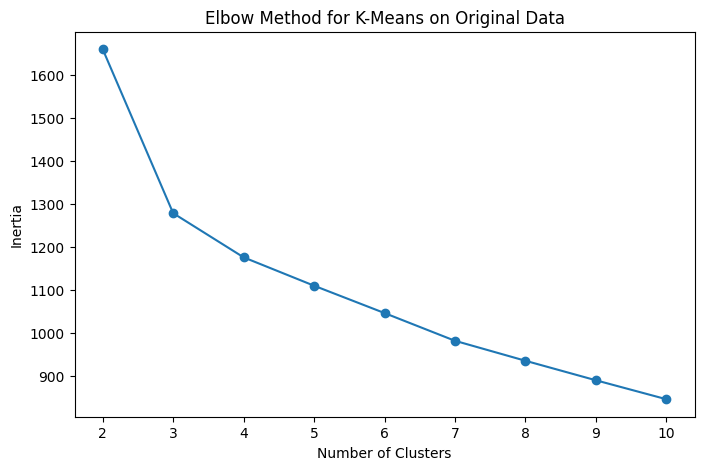

In [21]:
inertia_values = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method for K-Means on Original Data")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

## 20. Apply K-Means on Original Data

Since the Wine dataset has 3 known classes, we use `k = 3`.

In [22]:
k = 3

kmeans_original = KMeans(n_clusters=k, random_state=42, n_init=10)
original_clusters = kmeans_original.fit_predict(X_scaled)

df_original_clustered = df.copy()
df_original_clustered["Original_Cluster"] = original_clusters

display(df_original_clustered.head())

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,Original_Cluster
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2


## 21. Visualize Original Data Clusters using PCA Projection

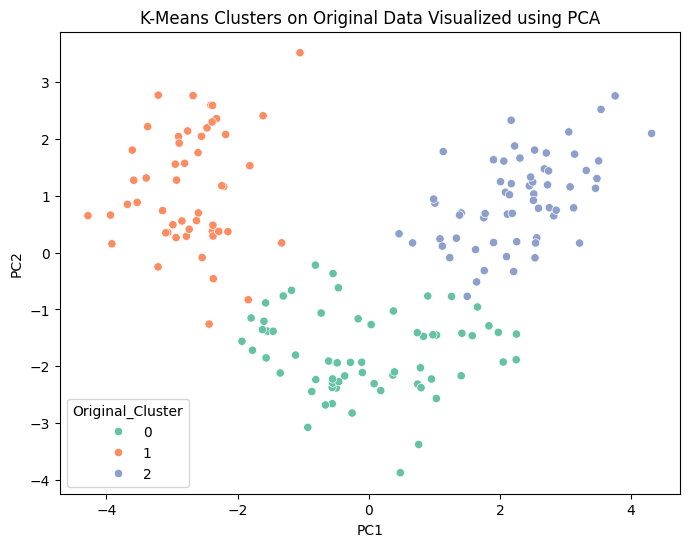

In [23]:
original_cluster_plot_df = pca_2_df.copy()
original_cluster_plot_df["Original_Cluster"] = original_clusters

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=original_cluster_plot_df,
    x="PC1",
    y="PC2",
    hue="Original_Cluster",
    palette="Set2"
)
plt.title("K-Means Clusters on Original Data Visualized using PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 22. Evaluate Clustering on Original Data

In [24]:
silhouette_original = silhouette_score(X_scaled, original_clusters)
db_original = davies_bouldin_score(X_scaled, original_clusters)

print("Original Data Clustering Evaluation")
print("-----------------------------------")
print("Silhouette Score:", round(silhouette_original, 4))
print("Davies-Bouldin Index:", round(db_original, 4))

Original Data Clustering Evaluation
-----------------------------------
Silhouette Score: 0.2849
Davies-Bouldin Index: 1.3892


# Task 4: Clustering with PCA Data

## 23. Apply K-Means on PCA-Transformed Data

We apply K-Means on the first 2 principal components.

In [25]:
kmeans_pca = KMeans(n_clusters=k, random_state=42, n_init=10)
pca_clusters = kmeans_pca.fit_predict(X_pca_2)

pca_clustered_df = pca_2_df.copy()
pca_clustered_df["PCA_Cluster"] = pca_clusters

display(pca_clustered_df.head())

,PC1,PC2,Type,PCA_Cluster
0,3.316751,1.443463,1,0
1,2.209465,-0.333393,1,0
2,2.516740,1.031151,1,0
3,3.757066,2.756372,1,0
4,1.008908,0.869831,1,0


## 24. Visualize PCA-Based Clusters

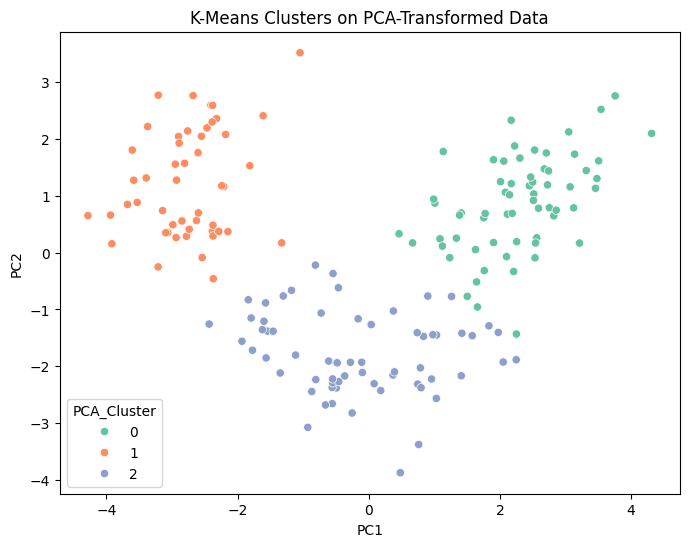

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_clustered_df,
    x="PC1",
    y="PC2",
    hue="PCA_Cluster",
    palette="Set2"
)
plt.title("K-Means Clusters on PCA-Transformed Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 25. Evaluate Clustering on PCA Data

In [27]:
silhouette_pca = silhouette_score(X_pca_2, pca_clusters)
db_pca = davies_bouldin_score(X_pca_2, pca_clusters)

print("PCA Data Clustering Evaluation")
print("------------------------------")
print("Silhouette Score:", round(silhouette_pca, 4))
print("Davies-Bouldin Index:", round(db_pca, 4))

PCA Data Clustering Evaluation
------------------------------
Silhouette Score: 0.5611
Davies-Bouldin Index: 0.5973


# Task 5: Comparison and Analysis

## 26. Compare Clustering Metrics

,Dataset,Silhouette Score,Davies-Bouldin Index
0,Original Standardized Data,0.284859,1.389188
1,PCA-Transformed Data,0.561051,0.597266


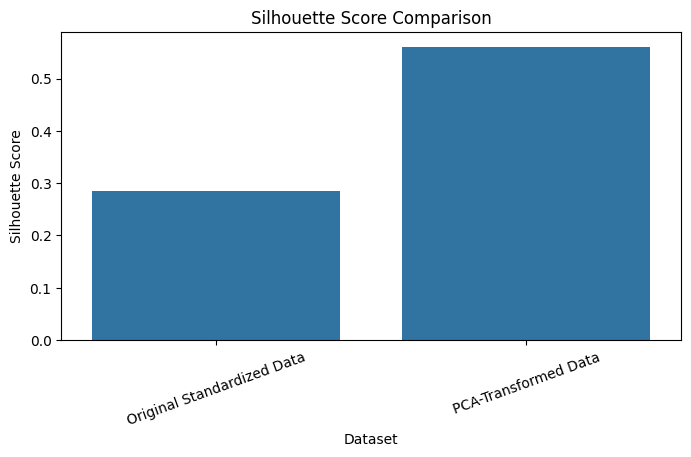

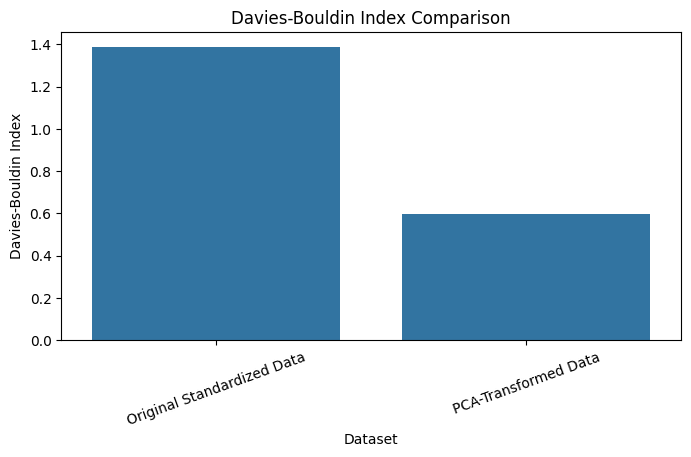

In [28]:
comparison_df = pd.DataFrame({
    "Dataset": ["Original Standardized Data", "PCA-Transformed Data"],
    "Silhouette Score": [silhouette_original, silhouette_pca],
    "Davies-Bouldin Index": [db_original, db_pca]
})

display(comparison_df)

plt.figure(figsize=(8,4))
sns.barplot(data=comparison_df, x="Dataset", y="Silhouette Score")
plt.title("Silhouette Score Comparison")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(data=comparison_df, x="Dataset", y="Davies-Bouldin Index")
plt.title("Davies-Bouldin Index Comparison")
plt.xticks(rotation=20)
plt.show()

## 27. Compare Actual Type with Clusters

In [29]:
print("Actual Type vs Original Data Clusters:")
display(pd.crosstab(df_original_clustered["Type"], df_original_clustered["Original_Cluster"]))

print("Actual Type vs PCA Data Clusters:")
display(pd.crosstab(pca_clustered_df["Type"], pca_clustered_df["PCA_Cluster"]))

Actual Type vs Original Data Clusters:


Original_Cluster,0,1,2
Type,,,
1,0,0,59
2,65,3,3
3,0,48,0


Actual Type vs PCA Data Clusters:


PCA_Cluster,0,1,2
Type,,,
1,59,0,0
2,5,1,65
3,0,48,0


## 28. Analysis of Results

### Similarities
Both original-data clustering and PCA-based clustering attempt to group wine samples based on chemical properties. Since PCA preserves the maximum variance in fewer dimensions, the clusters in PCA space often show similar grouping patterns to the original data.

### Differences
Original data uses all 13 numerical features, while PCA clustering uses only the first 2 principal components. This can make PCA clustering easier to visualize but may lose some information.

### Impact of PCA on Clustering
PCA reduces dimensionality and removes some noise from the dataset. This can improve clustering visualization and sometimes improve clustering performance. However, if too few components are selected, important information may be lost.

### Trade-Offs

| Approach | Advantages | Limitations |
|---|---|---|
| Clustering on Original Data | Uses all information | Hard to visualize, may contain noise |
| Clustering on PCA Data | Easier visualization, reduced noise | May lose information |

## 29. Practical Recommendations

Use PCA before clustering when:

1. Dataset has many features.
2. Features are highly correlated.
3. Visualization is needed.
4. Noise reduction is useful.
5. Faster computation is required.

Use clustering directly on original data when:

1. Dataset has fewer features.
2. Interpretability of original features is important.
3. You do not want to lose information.
4. Original features are already clean and meaningful.

# Task 6: Conclusion and Insights

## 30. Final Conclusion

In this assignment, PCA was applied to the Wine dataset for dimensionality reduction. The dataset was first explored using summary statistics, missing value checks, histograms, boxplots, pair plots, and a correlation heatmap.

Before applying PCA, all features were standardized because PCA is sensitive to feature scale. PCA was then applied to the standardized dataset. Scree plot and cumulative explained variance plot were used to determine how many principal components were needed to preserve most of the information.

K-Means clustering was applied first on the original standardized dataset and then on the PCA-transformed dataset. The clustering results were visualized using two principal components. Performance was evaluated using silhouette score and Davies-Bouldin index.

The comparison showed how PCA can simplify the dataset while preserving important patterns. PCA also helps improve visualization and reduce dimensionality. However, using too few principal components may result in information loss.

Overall, PCA is a useful technique when dealing with high-dimensional data, correlated features, and visualization needs. Clustering on PCA-transformed data can be effective when dimensionality reduction improves separation and reduces noise.